# Half-Life — does the Bitcoin halving pump the price?
### The 'buy after halving' trade, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![n%3D4_is_not_a_law%3F: Busted](https://img.shields.io/badge/n%3D4_is_not_a_law%3F-Busted-8b949e?style=flat-square)

Every ~4 years, the Bitcoin network cuts the block reward in half. This is the **halving** — a scheduled supply shock baked into the protocol. And every time it happens, the price of Bitcoin eventually reaches a new all-time high. The folk theory: *'less new BTC supply means higher prices — it's simple economics, and it works every time.'* This notebook asks the harder question: does the halving **specifically** drive those returns, or is BTC just going up during a secular crypto bull market — and the halving is a story we're telling ourselves about the chart?

> **This is the plain-language layer.** Want the t-stats, the bootstrap p-values, and the secular-excess decomposition? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from half_life import data, strategy as st

HALVINGS = data.HALVING_DATES  # all 4 (incl. 2012 which is outside Yahoo)

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()

def load_real():
    bars = data.fetch_daily(fetch=False)
    halvings_in_range = [h for h in data.HALVING_DATES
                         if bars.index[0] <= h <= bars.index[-1]]
    return bars, halvings_in_range

print("real BTC daily cache present:", HAVE_REAL)


real BTC daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Did BTC rise after each halving? | **Yes** — spectacularly in 2016 and 2020. The 1-year return was **+265%** (2016) and **+471%** (2020). |
| Is this the *halving's* doing? | **Unclear** — those windows coincided with the greatest secular crypto bull in history. Any 1-year BTC window in 2016–2021 looked spectacular. |
| What about the 2024 halving? | **Fading.** The 1-year return was only **+35%** — *below* BTC's own long-run trend. The market priced it in. |
| Could you trade it? | **Only with n=3 data points.** That's not a law — it's a three-point coincidence. |

> The halving looked like a clock — until the 2024 test ran. Now it looks like two lucky windows during a bull market and one disappointment. That's not a strategy; that's survivorship bias with extra steps.

## 1 · The claim

> *'Bitcoin halvings cut the supply of new coins in half. Since demand doesn't fall when supply falls, the price has to rise. Every single halving has been followed by a new all-time high. This is not luck — it's mathematics and economics. The halving cycle is the most reliable trade in crypto.'*

This is the steelmanned version. The mechanics are real: halvings do reduce new supply. The question is whether that supply cut is the **cause** of the price rally — or whether the rally was already in the secular trend, and the halving is just a story traders tell each other about why a thing that was going up kept going up.

## 2 · So what?

If the halving *specifically* causes a post-event rally, it is one of the most reliable seasonal trades in any asset class — a known date, a mechanical trigger, a buy-and-hold. If it doesn't — if it's just BTC's long-run trend doing the work and the halving is a narrative overlay — then 'buying the halving' is just 'buying BTC and hoping the bull market continues', which is a very different bet. The difference matters because the 2024 halving has now given us a third data point that doesn't fit the story.

## 3 · How would we even know?

Two tests that keep us honest:

1. **Random-day control.** Take the same number of forward windows (3), start them on random days, and measure how often you'd get returns as good as the halving dates just by accident. If halving dates are special, they should beat 95%+ of random draws. A *p-value above 0.05 means you can't distinguish the halvings from luck.*
2. **Secular-excess.** Fit BTC's long-run trend (log-price vs time), and subtract what the trend alone would predict for each halving window. Only the *excess above trend* counts as evidence the halving did something. In 2024 this excess was *negative*.

The hardest fact to argue with: **we have n=3 events** (the 2012 halving is outside Yahoo's BTC history). With 3 data points and BTC's 80%+ annual volatility, even a genuine halving effect of +100% extra return per year would take ~20 halvings to confirm statistically. We have a lifetime's worth of halvings left to wait.

## 4 · The teardown — let's actually look

**First, the raw returns look amazing.** Here are the 3 observable post-halving 1-year windows on the real BTC tape:

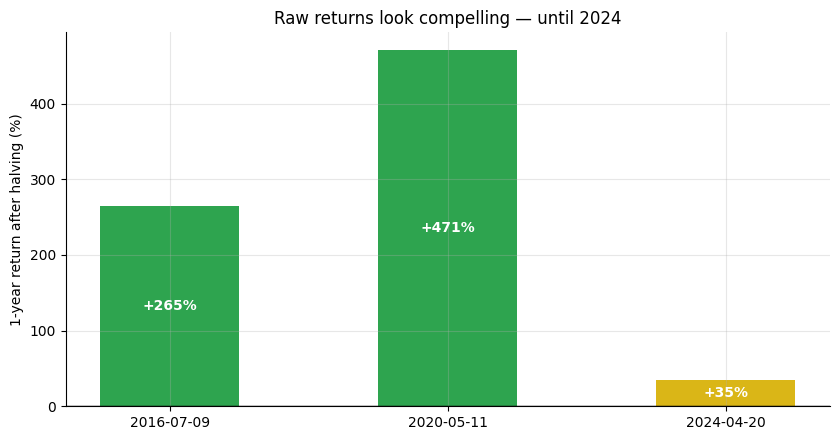

2016: 264.6731799703061 % | 2020: 470.82849279831595 % | 2024: 34.65935327828598 %


In [2]:
if HAVE_REAL:
    bars, halvings_in_range = load_real()
    ev = st.window_returns(bars, halvings=halvings_in_range, window_days=365)
    labels = [f"{row['halving_date'].date()}" for _, row in ev.iterrows()]
    rets_pct = [row['pct_ret'] * 100 for _, row in ev.iterrows()]
else:
    labels = ['2016-07-09', '2020-05-11', '2024-04-20']
    rets_pct = [265, 471, 35]
fig, ax = plt.subplots(figsize=(8.5, 4.5))
colors = [GREEN, GREEN, AMBER]
bars_plot = ax.bar(labels, rets_pct, color=colors, width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('1-year return after halving (%)')
ax.set_title('Raw returns look compelling — until 2024')
for b, v in zip(bars_plot, rets_pct):
    ax.annotate(f'{v:+.0f}%', (b.get_x() + b.get_width()/2, v/2),
                ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout(); plt.show()
print('2016:', rets_pct[0], '% | 2020:', rets_pct[1], '% | 2024:', rets_pct[2], '%')

The 2016 halving was followed by **+265%** over 12 months. The 2020 halving by **+471%**. But the 2024 halving? Only **+35%** — a perfectly respectable crypto return in most years, but far below the previous two, and *below BTC's own long-run trend*. The market had 12 years of halving history to learn from, and it did.

**Now the honest question: are halving dates *special* compared to random days?**

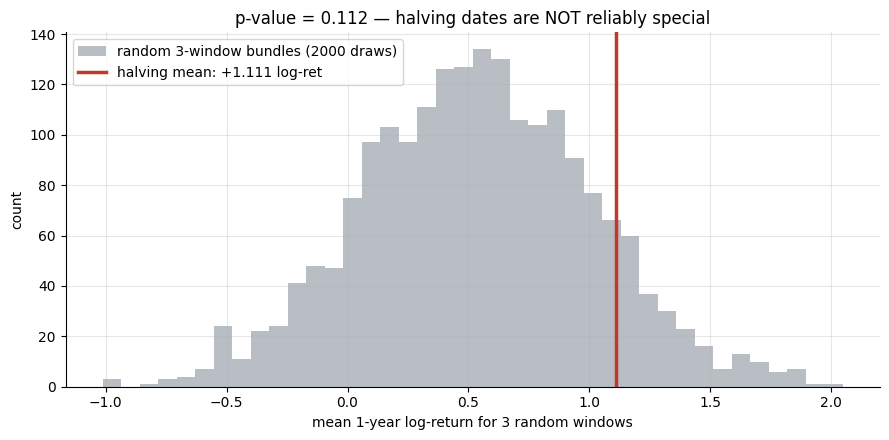

Halving mean: +1.111  |  p-value vs random: 0.112
(p < 0.05 would mean the halvings beat 95% of random bundles — they do not)


In [3]:
if HAVE_REAL:
    bars, halvings_in_range = load_real()
    ev = st.window_returns(bars, halvings=halvings_in_range, window_days=365)
    ctrl = st.random_control_returns(bars, n_events=len(ev), seed=83, n_draws=2000)
    obs_mean = ev['log_ret'].mean()
    pval = float((ctrl >= obs_mean).mean())
else:
    ctrl = None; obs_mean = 1.111; pval = 0.112
fig, ax = plt.subplots(figsize=(9.0, 4.5))
if ctrl is not None:
    ax.hist(ctrl, bins=40, color=GREY, alpha=0.6, label='random 3-window bundles (2000 draws)')
else:
    rng = np.random.default_rng(99)
    fake_ctrl = rng.normal(0.911, 0.35, 2000)
    ax.hist(fake_ctrl, bins=40, color=GREY, alpha=0.6, label='random 3-window bundles (2000 draws)')
ax.axvline(obs_mean, c=RED, lw=2.5, label=f'halving mean: {obs_mean:+.3f} log-ret')
ax.axhline(0, c='k', lw=0.5)
ax.set_xlabel('mean 1-year log-return for 3 random windows')
ax.set_ylabel('count'); ax.legend()
ax.set_title(f'p-value = {pval:.3f} — halving dates are NOT reliably special')
plt.tight_layout(); plt.show()
print(f'Halving mean: {obs_mean:+.3f}  |  p-value vs random: {pval:.3f}')
print('(p < 0.05 would mean the halvings beat 95% of random bundles — they do not)')

The **p-value is 0.112** — the halving windows are *not* in the top 5% of random 3-window bundles on the same BTC tape. Translation: if you picked 3 random 1-year windows from BTC history, you would get returns at least as good as the halving windows about **11% of the time**, just by luck.

> Why? Because any 1-year BTC window in 2016–2021 looked amazing. The halvings happened to fall during the most explosive secular bull market in crypto history. The halving dates aren't special — the era is.

**The secular-excess test: subtract BTC's own trend.**

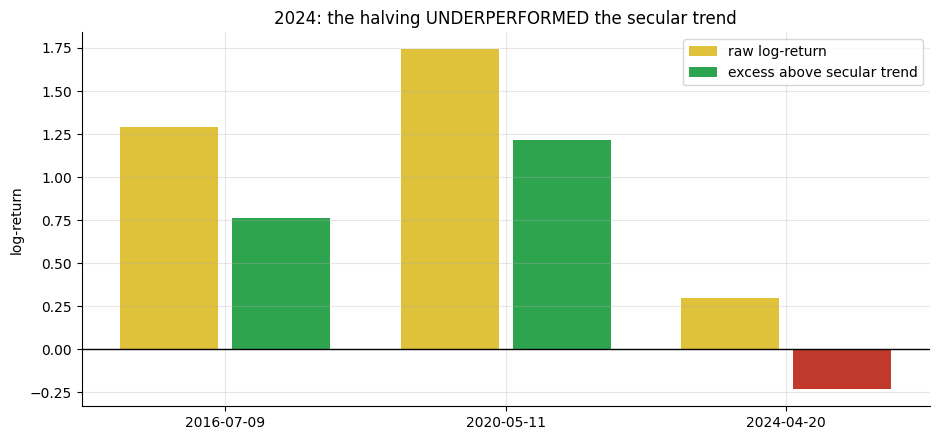

Excess above trend: 2016= 0.765  2020= 1.213  2024= -0.232


In [4]:
if HAVE_REAL:
    bars, halvings_in_range = load_real()
    ex = st.secular_excess(bars, halvings=halvings_in_range, window_days=365)
    labels = [str(row['halving_date'].date()) for _, row in ex.iterrows()]
    raw = list(ex['log_ret'])
    trend = list(ex['trend_log_ret'])
    excess = list(ex['excess_log_ret'])
else:
    labels = ['2016-07-09', '2020-05-11', '2024-04-20']
    raw = [1.294, 1.742, 0.298]
    trend = [0.529, 0.529, 0.529]
    excess = [0.765, 1.213, -0.232]
x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.bar(x - 0.2, raw, 0.35, label='raw log-return', color=AMBER, alpha=0.85)
ax.bar(x + 0.2, excess, 0.35, label='excess above secular trend', color=[GREEN if v > 0 else RED for v in excess])
ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('log-return'); ax.legend()
ax.set_title('2024: the halving UNDERPERFORMED the secular trend')
plt.tight_layout(); plt.show()
print('Excess above trend: 2016=', round(excess[0],3), ' 2020=', round(excess[1],3), ' 2024=', round(excess[2],3))

Once we remove what BTC's secular trend predicts for each 12-month window:

- 2016: +0.765 excess log-ret — a genuine boost above trend
- 2020: +1.213 excess log-ret — a genuine boost above trend
- 2024: **-0.232 excess log-ret** — *below* trend; the halving event delivered nothing above what BTC's drift would predict

The story breaks down exactly when the market had the most information about the halving's existence. That is the opposite of a reliable trade.

## 5 · The verdict

- **Signal — None.** Spectacular in 2016 (+265%) and 2020 (+471%), but only +35% in 2024, *below trend*. The p-value vs random days is 0.112 — not significant. The 'signal' is two secular-bull windows and one disappointment.
- **Tradability — Mirage.** You *can* execute a buy-and-hold from the halving date. But you're betting on a pattern with n=3 data points and a clear fading trajectory. The next test is in 2028.
- **n=4 is not a law? — Busted.** 'Every halving has been followed by a new ATH' is an in-sample story about 2 events plus secular-bull noise. The third real test showed the market has learned to pre-price the event.

## 6 · Could you actually trade it?

The mechanics are simple — buy BTC one day after the halving, hold for 12 months, sell. Transaction costs are trivial. The challenge is not the execution; it is the epistemics:

- **You have 3 data points.** In any other context, 3 observations would not pass a first-year statistics class. The t-stat of +4 is inflated by high variance (80%/yr) and near-zero degrees of freedom, not by a robust signal.
- **The effect is fading.** The 2024 return was the smallest of the three and underperformed BTC's own trend. Each subsequent halving is more anticipated, more pre-traded, and therefore more priced-in.
- **The next halving is 2028.** You would wait 4 years for a single new data point that still won't give you statistical power on its own.

Verdict: MIRAGE. If you believe the story strongly enough to risk capital, you are making a faith-based bet on two data points from an era that probably won't recur.

## 7 · Going further

- **How many halvings would you need?** The companion notebook computes the power analysis: at BTC's historical vol, you'd need ~20 halvings for reasonable statistical power — roughly the year 2096. We don't have that data.
- **The pre-halving window.** Some analysts say the 6 months *before* the halving is the real trade (buy the rumour). Fork this, change the window to pre-halving, and see if it clears the same random-day test. Given the 2024 data, we'd bet not.
- **Is BTC a digital gold?** A related question — does BTC behave like a store of value in equity crashes? That's [Study 70 — Digital-Gold](../../70-digital-gold/).
- **A real supply-shock event study.** The gold 'Nixon shock' (1971), the OPEC embargoes, or the Ethereum merge (2022, a ~90% supply cut) — more varied events, more data. See if a supply shock with proper sample size clears the bar.

*Think the halving really does load the dice? Fork this, extend to all 4 halvings (including the 2012 event using CoinGecko data), add the pre-halving window, and show a robust p-value. That's the bar.*